
--- 請開始輸入 4 個物品的資訊 ---


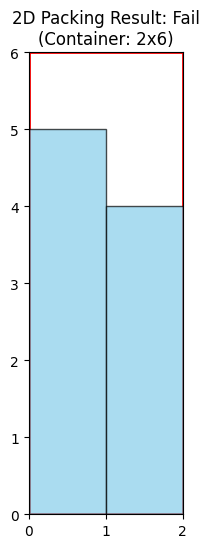

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def ffdh_packing_with_input():
    # 1. 輸入背包 M*N
    try:
        M = int(input("請輸入背包寬度 M: "))
        N = int(input("請輸入背包高度 N: "))
        num_items = int(input("請輸入物品總數: "))
    except ValueError:
        print("輸入錯誤！請確保輸入的是整數。")
        return

    # 2. 輸入每個物品的長寬
    items = []
    print(f"\n--- 請開始輸入 {num_items} 個物品的資訊 ---")
    for i in range(num_items):
        try:
            line = input(f"第 {i+1} 個物品的 [寬 高] (空白分隔，例如 5 10): ")
            w, h = map(int, line.split())
            
            # 基本檢查：物品不能比背包大
            if w > M or h > N:
                print(f"警告：物品 {w}x{h} 超出背包尺寸，將無法放入！")
            items.append((w, h))
        except ValueError:
            print("格式錯誤，請重新執行 Cell 並確保輸入兩個數字。")
            return

    # 3. 執行 FFDH 演算法 (架子演算法)
    # 先按高度由大到小排序
    sorted_items = sorted(items, key=lambda x: x[1], reverse=True)
    
    placed_rects = []
    curr_x, curr_y = 0, 0
    shelf_h = 0
    can_fit_all = True
    
    for w, h in sorted_items:
        if curr_x + w > M:
            # 換行 (開闢新架子)
            curr_y += shelf_h
            curr_x = 0
            shelf_h = 0
            
        if curr_y + h > N:
            can_fit_all = False
            break
            
        placed_rects.append((curr_x, curr_y, w, h))
        curr_x += w
        shelf_h = max(shelf_h, h)

    # 4. 繪圖結果
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(0, M)
    ax.set_ylim(0, N)
    ax.set_aspect('equal')
    ax.add_patch(patches.Rectangle((0, 0), M, N, fill=None, edgecolor='red', linewidth=2, label='Backpack'))
    
    for x, y, w, h in placed_rects:
        ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='skyblue', edgecolor='black', alpha=0.7))
        
    status = "Success" if can_fit_all else "Fail"
    plt.title(f"2D Packing Result: {status}\n(Container: {M}x{N})")
    plt.show()

# 啟動輸入流程
ffdh_packing_with_input()